<a href="https://colab.research.google.com/github/d4nd14z/DataAnalytics/blob/main/MineriaDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Minería de Datos**<br/>Daniel Mauricio Díaz Forero<br/>Johan Andrey Mina Forero<br/>Universidad de La Salle<br/>Febrero 23 de 2026

In [2]:
# Activar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Importacion de Librerias
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Funcion para dibujar los tres graficas
# Recibe como parametro el nombre de la columna que se va a graficar.
def mostrarGraficas(nombre_columna:str):
  # Se ajustan las graficas para que la figura sea: 1 fila, 3 columnas y el tamaño total (ancho, alto)
  fig, axes = plt.subplots(1, 3, figsize=(17, 5))

  # --- Diagrama 1: Histograma ---
  sns.histplot(x=df[nombre_columna], bins=50, ax=axes[0], color='royalblue', edgecolor='white', linewidth=0.5, alpha=0.7)
  axes[0].set_title('Histograma (Agrupado por Bins)')

  # --- Diagrama 2: Boxplot ---
  sns.boxplot(
    x=df[nombre_columna],
    ax=axes[1],
    color='#00FF00',     # Color de la caja
    width=0.7,           # Ancho de la caja
    linewidth=1,         # Ancho del borde de la caja
    fliersize=4,
    flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "none",
        "alpha": 0.4
    },
    boxprops={"edgecolor": "black", "alpha": 0.8} # Borde negro fino para resaltar el verde
  )
  axes[1].set_title('Boxplot (Diagrama de Cajas)')

  # --- Diagrama 3: Dispersión ---
  # Como es una sola variable, graficamos los puntos según su índice
  sns.scatterplot(x=df.index, y=df[nombre_columna], ax=axes[2], color='red')
  axes[2].set_title('ScatterPlot (Diagrama de Dispersión)')
  axes[2].set_xlabel(nombre_columna)

  # Ajustar el espacio entre gráficas para que no se encimen
  plt.tight_layout()
  plt.show()

### **1. Lectura del Conjunto de Datos**

In [4]:
path_dataset = "/content/drive/MyDrive/Universidad de La Salle/Minería de datos/data/yellow_tripdata_2017-01 1.parquet"
try:
  if not os.path.exists(path_dataset):
    raise Exception(f"El conjunto de datos no existe.")
  df = pd.read_parquet(path_dataset)
  # Cargar aquí la librería para los gráficos !!!
except Exception as ex:
  print(f"(ERROR): No se ha podido leer el conjunto de datos.")
  print(f"\n{ex}")

In [ ]:
# Mostrar las columnas y el tipo de datos de cada una
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9710820 entries, 0 to 9710819
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   object        
 18  airport_fee           

In [ ]:
# Obtener el valor total de registros y columnas del Dataset
df.shape
print(f"El conjunto de datos contiene: {df.shape[0]} filas y {df.shape[1]} columnas.\n", "*"*100)

# Mostrar el conteo de variables numericas y variables de otro tipo.
tipos_numericos = ["int64", "float64"]
nums, strs = 0, 0
for col in df.columns:
  if df[col].dtype in tipos_numericos:
    nums += 1
  else:
    strs += 1
print(f"El conjunto de datos contiene {nums} variables numericas y {strs} variables de otros tipos.\n", "*"*100)

El conjunto de datos contiene: 9710820 filas y 19 columnas.
 ****************************************************************************************************
El conjunto de datos contiene 14 variables numericas y 5 variables de otros tipos.
 ****************************************************************************************************


In [ ]:
# Averiguar cuantos valores nulos hay dentro de cada una de las columnas del DataFrame
df.isnull().sum() # Por cada una de las columnas del Dataframe, encuentre todos los valores nulos (isnull) y sumelos (sum)

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [ ]:
df_no_numerico = df.select_dtypes(exclude=["number"]).copy() # Extraer dentro de una copia del DataFrame unicamente los variables que NO sean de tipo "numerico"
df_numerico = df.select_dtypes(include=['number']).copy() # Extraer dentro de una copia del DataFrame unicamente los variables que sean de tipo "numerico"

In [ ]:
# MOstrar copia del DataSet con variables no numericas
df_no_numerico

,tpep_pickup_datetime,tpep_dropoff_datetime,store_and_fwd_flag,congestion_surcharge,airport_fee
0,2017-01-01 00:32:05,2017-01-01 00:37:48,N,None,None
1,2017-01-01 00:43:25,2017-01-01 00:47:42,N,None,None
2,2017-01-01 00:49:10,2017-01-01 00:53:53,N,None,None
3,2017-01-01 00:36:42,2017-01-01 00:41:09,N,None,None
4,2017-01-01 00:07:41,2017-01-01 00:18:16,N,None,None
...,...,...,...,...,...
9710815,2017-01-31 23:04:11,2017-01-31 23:10:56,N,None,None
9710816,2017-01-31 23:32:46,2017-01-31 23:40:14,N,None,None
9710817,2017-01-31 23:23:22,2017-01-31 23:38:38,N,None,None
9710818,2017-01-31 23:48:10,2017-01-31 23:57:15,N,None,None


In [ ]:
# MOstrar copia del DataSet con variables numericas
df_numerico

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,1,1.20,1,140,236,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80
1,1,2,0.70,1,237,140,2,5.0,0.5,0.5,0.00,0.0,0.3,6.30
2,1,2,0.80,1,140,237,2,5.5,0.5,0.5,0.00,0.0,0.3,6.80
3,1,1,1.10,1,41,42,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30
4,1,1,3.00,1,48,263,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9710815,2,2,1.04,1,148,45,1,6.5,0.5,0.5,1.56,0.0,0.3,9.36
9710816,1,4,1.60,1,264,264,1,8.0,0.5,0.5,1.50,0.0,0.3,10.80
9710817,2,1,3.65,1,148,48,1,13.5,0.5,0.5,2.96,0.0,0.3,17.76
9710818,2,1,0.93,1,249,79,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80


### **2. Limpieza de datos y búsqueda de valores atípicos**

### **2.1 Búsqueda de valores duplicados**

In [5]:
df[df.duplicated()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


No se encuentran registros o filas completas que se encuentren completamente duplicadas en cada una de las coumnas del DataFrame

In [6]:
df[df.duplicated(keep=False)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


### **2.2 Variables NO Numéricas**

### **2.2.1 tpep_pickup_datetime**<br/>Esta variable contiene únicamente valores de tipo fecha-tiempo, por tanto no puede obtenerse un diagrama de Boxplot para identificar los valores atipicos sobre la variable. Es decir desde que el valor contenga una fecha válida, no podrá ser un "Valor atípico"

In [ ]:
# Obtener los valores unicos de la columna "tpep_pickup_datetime"
data = df_no_numerico["tpep_pickup_datetime"].unique()
print(len(data)) # Se encontraron 2383471 valores distintos
print(data)

2383471
<DatetimeArray>
['2017-01-01 00:32:05', '2017-01-01 00:43:25', '2017-01-01 00:49:10',
 '2017-01-01 00:36:42', '2017-01-01 00:07:41', '2017-01-01 00:20:52',
 '2017-01-01 00:33:49', '2017-01-01 00:48:22', '2017-01-01 00:57:12',
 '2017-01-01 00:10:25',
 ...
 '2017-01-31 23:55:25', '2017-01-31 23:47:38', '2017-01-31 23:47:37',
 '2017-01-31 23:03:56', '2017-01-31 23:37:20', '2017-01-31 23:19:52',
 '2017-01-31 23:39:19', '2017-01-31 23:13:28', '2017-01-31 23:39:22',
 '2017-01-31 23:15:24']
Length: 2383471, dtype: datetime64[us]


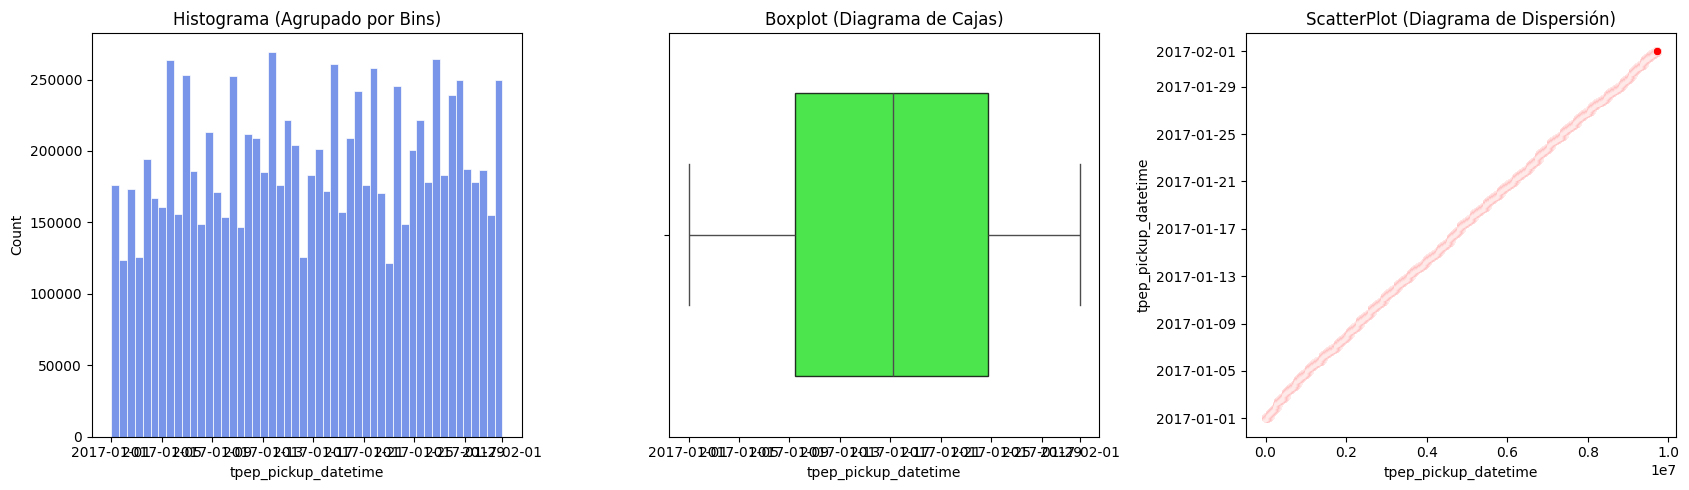

In [ ]:
mostrarGraficas("tpep_pickup_datetime")

### **2.2.2 tpep_dropoff_datetime**<br/>Al igual que la anterior variable, esta variable contiene únicamente valores de tipo fecha-tiempo, por tanto no puede obtenerse un diagrama de Boxplot para identificar los valores atipicos sobre la variable. Es decir desde que el valor contenga una fecha válida, no podrá ser un "Valor atípico"

In [ ]:
# Obtener los valores unicos de la columna "tpep_dropoff_datetime"
data = df_no_numerico["tpep_dropoff_datetime"].unique()
print(len(data)) # Se encontraron 2387055 valores distintos
print(data)

2387055
<DatetimeArray>
['2017-01-01 00:37:48', '2017-01-01 00:47:42', '2017-01-01 00:53:53',
 '2017-01-01 00:41:09', '2017-01-01 00:18:16', '2017-01-01 00:24:59',
 '2017-01-01 00:42:38', '2017-01-01 00:52:15', '2017-01-01 01:06:28',
 '2017-01-01 00:29:06',
 ...
 '2017-02-01 00:05:02', '2017-02-01 00:11:10', '2017-02-01 00:20:52',
 '2017-01-31 23:46:42', '2017-02-01 00:27:16', '2017-01-31 23:46:36',
 '2017-02-01 00:00:10', '2017-02-01 00:06:08', '2017-02-01 00:00:16',
 '2017-01-31 23:57:15']
Length: 2387055, dtype: datetime64[us]


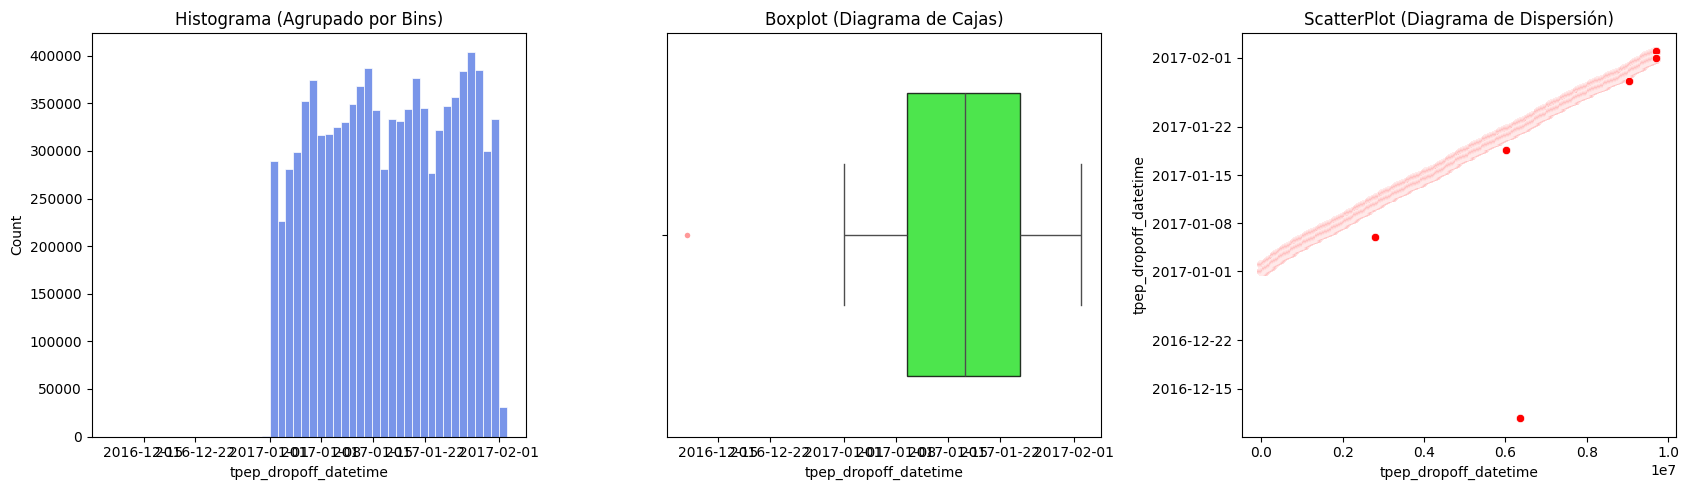

In [ ]:
mostrarGraficas("tpep_dropoff_datetime")

### **2.2.3 store_and_fwd_flag**<br/>Esta variable corresponde a una variable categórica donde se presentan únicamente dos valores posibles dentro de ella 'Y' y 'N'. No es posible detectar valores atípicos sobre esta variable.

In [ ]:
# Obtener los valores unicos de la columna "store_and_fwd_flag"
data = df_no_numerico["store_and_fwd_flag"].unique()
print(len(data)) # Se encontraron 2 valores distintos
print(data)

2
['N' 'Y']


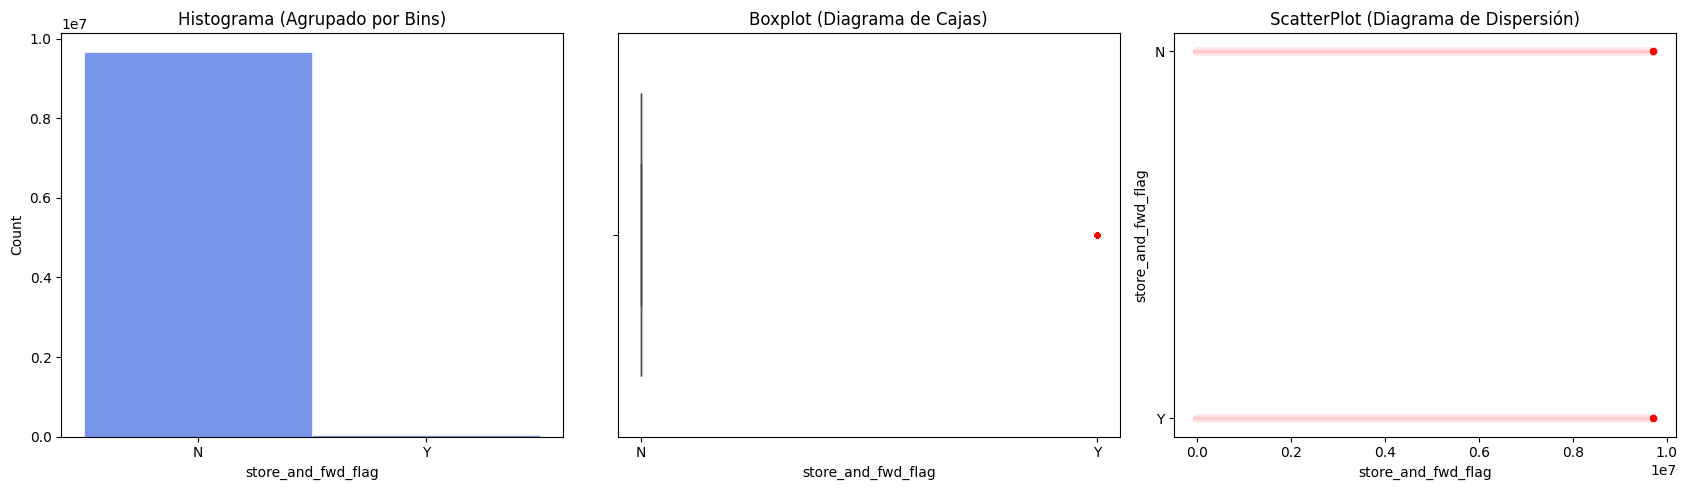

In [ ]:
mostrarGraficas("store_and_fwd_flag")

### **2.2.4 congestion_surcharge**<br/>Todos los valores de esta columna son valores nulos. Dado que los valores no pueden ser "calculados" ni "interpolados" a partir de otras variables del conjunto de datos, toda esta variable es candidata para ser eliminada del estudio.

In [ ]:
# Obtener los valores unicos de la columna "store_and_fwd_flag"
data = df_no_numerico["congestion_surcharge"].unique()
print(len(data)) # Se encontraron 1 valores distintos
print(data)

1
[None]


### **2.2.5 airport_fee**<br/>Al igual que la anterior, todos los valores de esta columna son valores nulos. Dado que los valores no pueden ser "calculados" ni "interpolados" a partir de otras variables del conjunto de datos, toda esta variable también es candidata para ser eliminada del estudio.

In [ ]:
# Obtener los valores unicos de la columna "store_and_fwd_flag"
data = df_no_numerico["airport_fee"].unique()
print(len(data)) # Se encontraron 1 valores distintos
print(data)

1
[None]


### **2.3 Variables Numéricas**

### **2.3.1 VendorID**

In [ ]:
#Obtener los distintos valores que hay sobre la variable VendorID
df_numerico["VendorID"].unique()

array([1, 2])

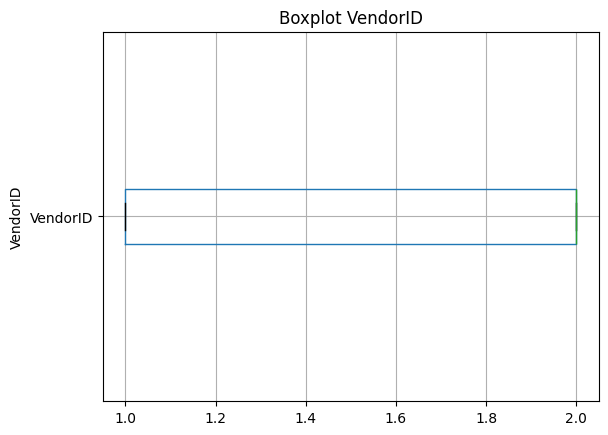

In [ ]:
# Graficar Boxplot para la variable "VendorID" del conjunto de datos
df_numerico.boxplot(column="VendorID", vert=False)
plt.title("Boxplot VendorID")
plt.ylabel("VendorID")
plt.show()

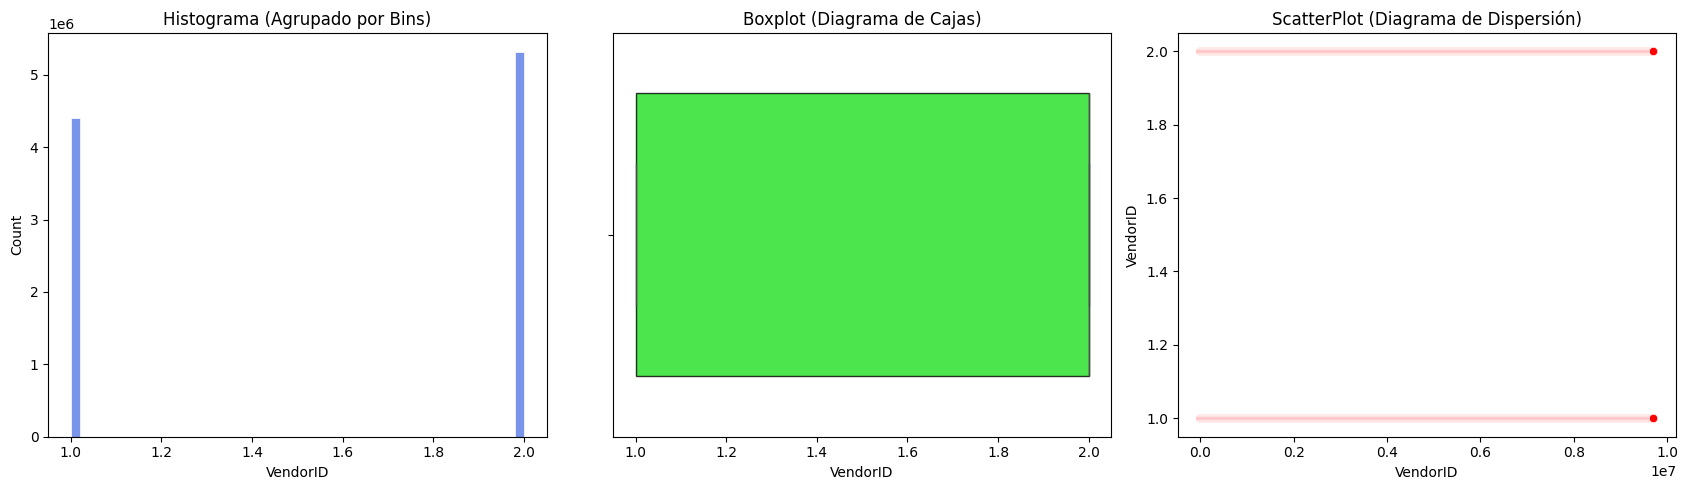

In [ ]:
mostrarGraficas("VendorID")

### **2.3.2 Passenger Count**

In [ ]:
# Obtener los distintos valores que hay sobre la variable Passenger_Count
df_numerico["passenger_count"].unique()

array([1, 2, 4, 3, 6, 5, 0, 8, 7, 9])

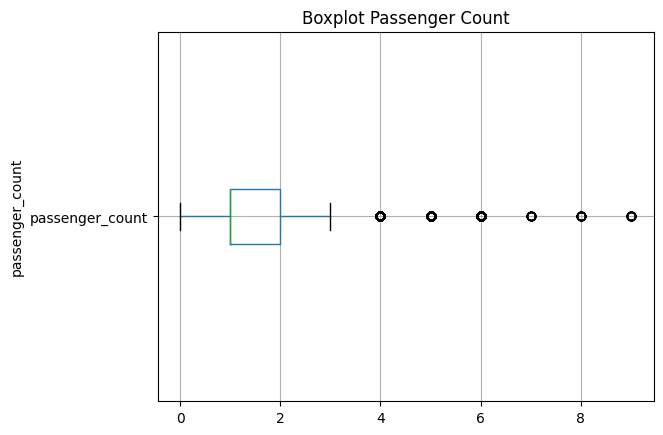

In [ ]:
# Graficar Boxplot para la variable "VendorID" del conjunto de datos
df_numerico.boxplot(column="passenger_count", vert=False)
plt.title("Boxplot Passenger Count")
plt.ylabel("passenger_count")
plt.show()

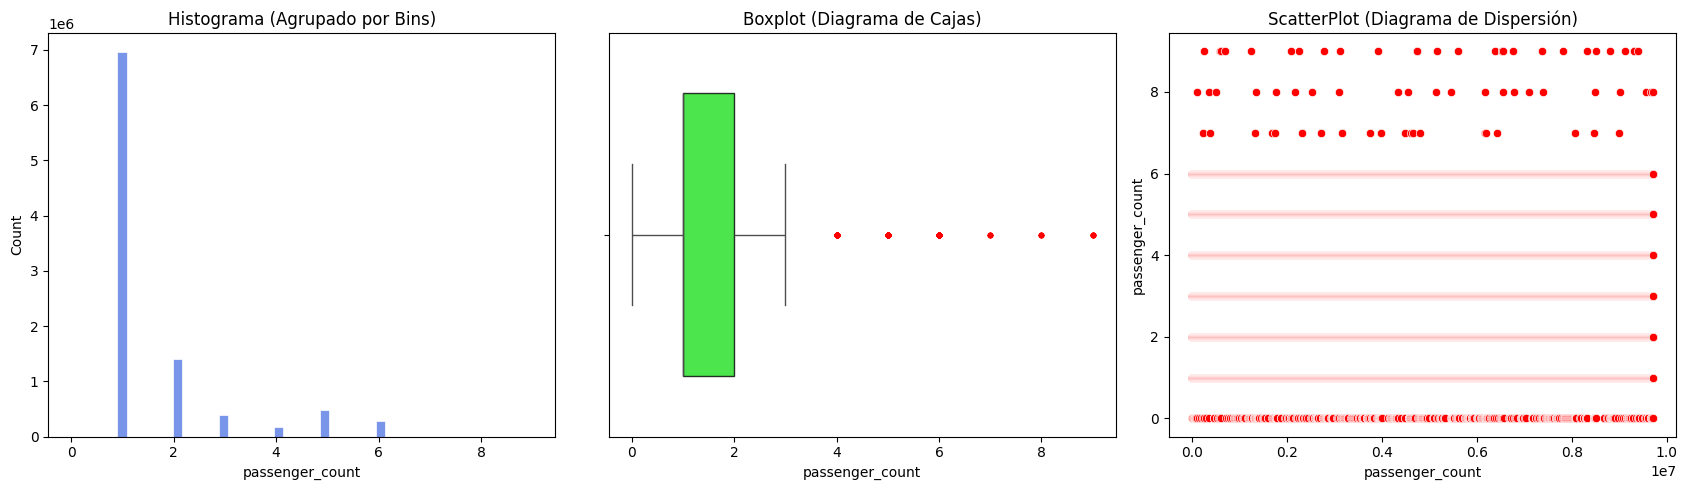

In [ ]:
mostrarGraficas("passenger_count")

### **2.3.3 Trip Distance**

In [ ]:
#Obtener los distintos valores que hay sobre la variable Trip Distance
df_numerico["trip_distance"].unique()

array([ 1.2 ,  0.7 ,  0.8 , ..., 48.15, 42.52, 61.63])

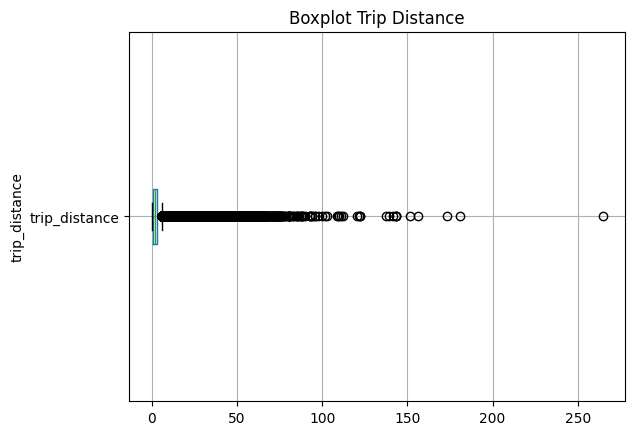

In [ ]:
# Graficar Boxplot para la variable "VendorID" del conjunto de datos
df_numerico.boxplot(column="trip_distance", vert=False)
plt.title("Boxplot Trip Distance")
plt.ylabel("trip_distance")
plt.show()

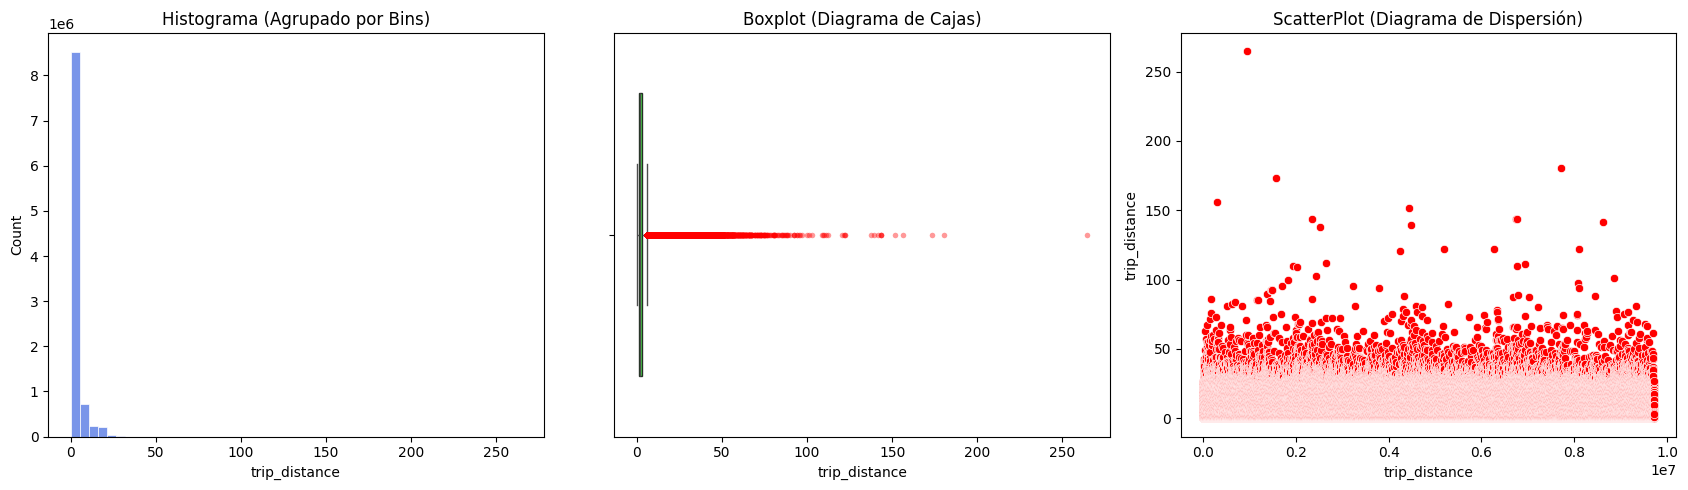

In [ ]:
# Graficar Boxplot para la variable "trip_distance" del conjunto de datos
#Como este se tan disperso... y como todos los valores están tan lejos de la caja, lo mejor es visualizarlos
#con un histograma, o observarlos también con un diagrama de dispersión.
mostrarGraficas("trip_distance")

### **2.3.4 Ratecode ID**

In [ ]:
#Obtener los distintos valores que hay sobre la variable Trip Distance
df_numerico["RatecodeID"].unique()

array([ 1,  2,  5,  4, 99,  3,  6])

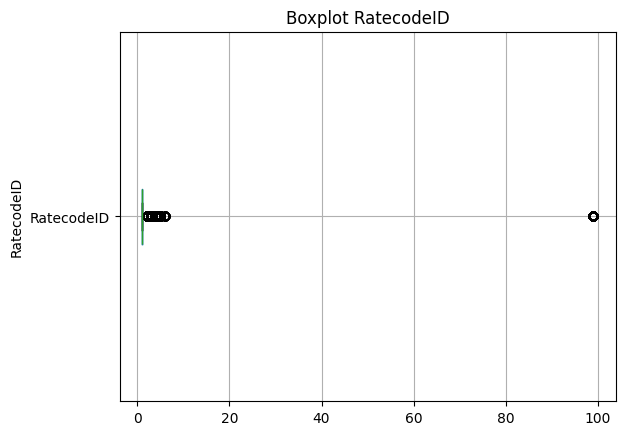

In [ ]:
# Graficar Boxplot para la variable "VendorID" del conjunto de datos
df_numerico.boxplot(column="RatecodeID", vert=False)
plt.title("Boxplot RatecodeID")
plt.ylabel("RatecodeID")
plt.show()

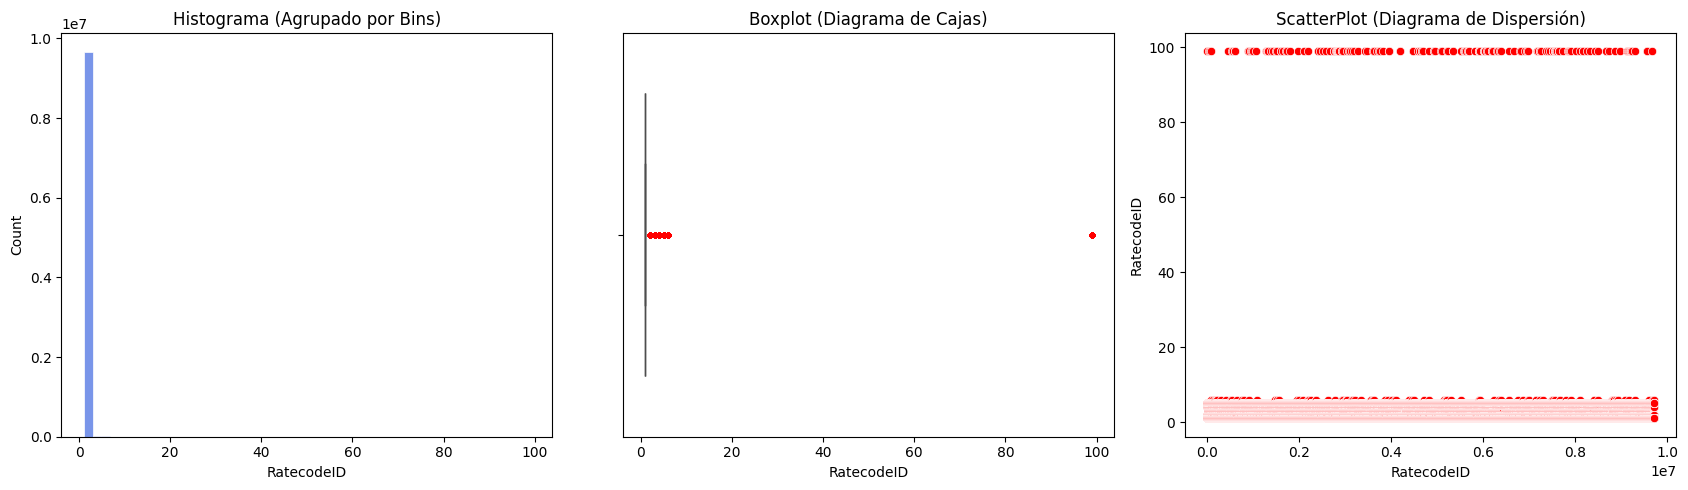

In [ ]:
mostrarGraficas("RatecodeID")

### **2.3.5 PULocation ID**

In [ ]:
#Obtener los distintos valores que hay sobre la variable Trip Distance
df_numerico["PULocationID"].unique()

array([140, 237,  41,  48, 236, 238, 239, 246, 114, 263, 161, 163, 107,
       186, 262, 249, 170, 211,  87, 151, 142,  80, 189, 234, 143, 132,
       229, 141,  50,  90, 113,  68, 145, 233,  75, 166, 152,  24,  43,
       158, 164, 137,  13, 148, 144, 248,  79,  88, 209, 231, 130, 100,
       125,  45,  65,   4, 116,  74, 162, 255, 224,  76,  56,   7, 190,
        62, 265, 264, 244,  25,  36,  42, 129, 179,  97, 230, 196, 226,
        95, 247, 232, 146, 257, 256, 261, 260, 112, 106, 193,  40, 181,
        89, 138,  37,  66, 223,  49,  83,  33, 225, 217,  17,  52, 127,
       168, 213, 212, 243, 215, 157, 177, 188,  82, 133, 192, 174,  78,
       167, 136, 119,  69, 198,  70,  35,  14,  61, 242, 134,  54, 160,
       228,  93,  51, 254,  94, 159, 126,  12, 235, 169,  85,  92, 156,
        63, 200,  20,  77, 195, 173, 121, 194, 153, 241,  47, 220, 202,
        60, 120,  96,  72, 185,  71,  18,  22,  31,  32,  28,  34, 250,
        39,  10, 122, 219, 227, 147, 216, 165, 197,  26,  53,  2

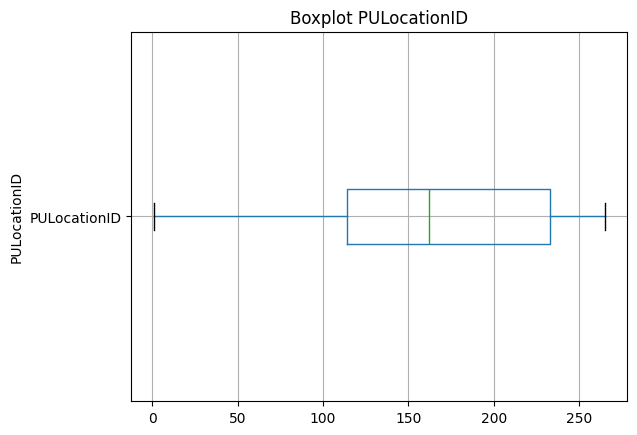

In [ ]:
# Graficar Boxplot para la variable "VendorID" del conjunto de datos
df_numerico.boxplot(column="PULocationID", vert=False)
plt.title("Boxplot PULocationID")
plt.ylabel("PULocationID")
plt.show()

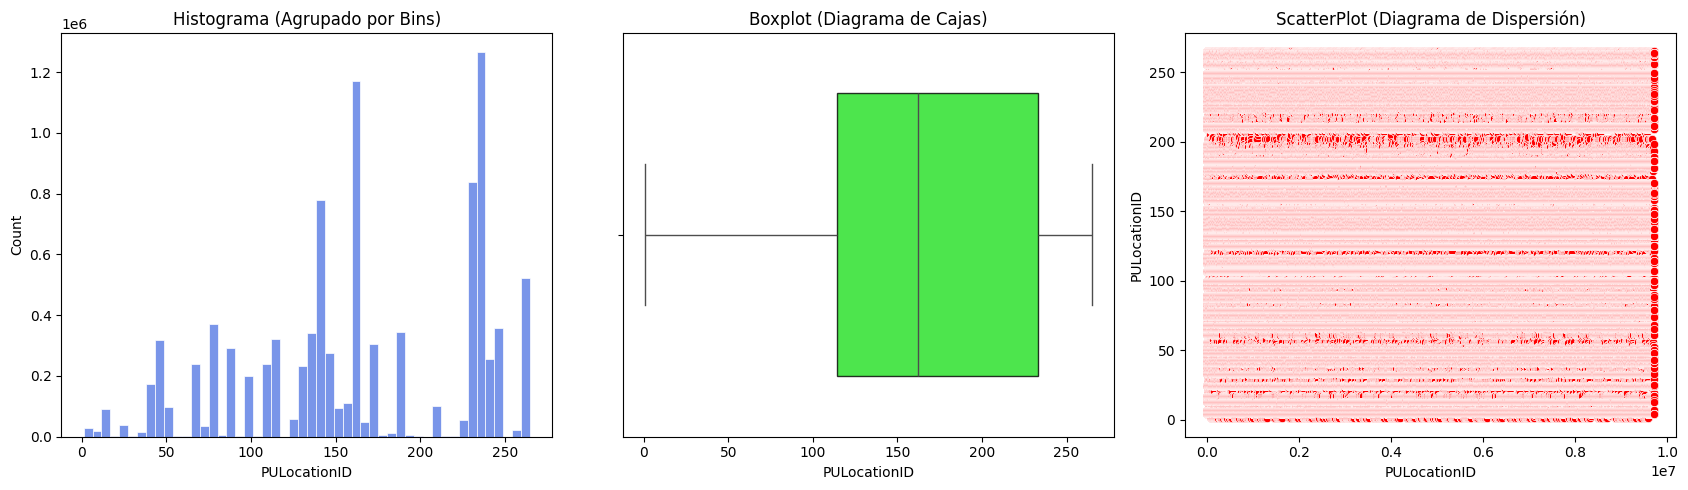

In [ ]:
mostrarGraficas("PULocationID")

### **2.3.6 DOLocation ID**

In [ ]:
df_numerico["DOLocationID"].unique()

array([236, 140, 237,  42, 263, 262, 238, 239,  48, 162,  79, 161, 145,
       224, 186, 170, 141,  43, 234, 211, 246,  13, 151, 114,  61,  85,
       257,  94,  62, 143,  92, 226, 229,  87,  90, 233, 243, 133,  75,
       264, 127, 116,  50, 137, 249,  24, 148, 144, 107, 142, 164, 163,
        47, 261, 132, 256, 166, 179,  41, 202, 113,  33,  89,  74, 181,
       168, 244,  39, 230,  78,  82,  68, 200,   4, 209, 125, 228, 158,
        76, 100,  91, 129, 223, 152, 188, 189,  49, 265,  88,  52, 231,
        45, 235,  25,  37,  17, 185, 167, 119, 255, 232,   7,  16, 173,
       126,  36,  14,  26, 198, 146,  70,  57, 134, 159,  18, 225,  40,
       247, 169,  12,  95,  65,  80, 196, 197, 112,  83, 193,  10,  56,
        97, 123,  22,  66, 160, 195, 205, 128,  72, 165, 227,  71, 260,
       139, 136, 177, 220, 241, 130, 182, 155, 213, 212,  32,   3,  69,
       219, 138, 106,  77, 190, 216,  15, 253, 157, 214,  60, 240, 217,
        28,  73, 135,  53, 174, 208, 175, 183, 120, 178,  35,  6

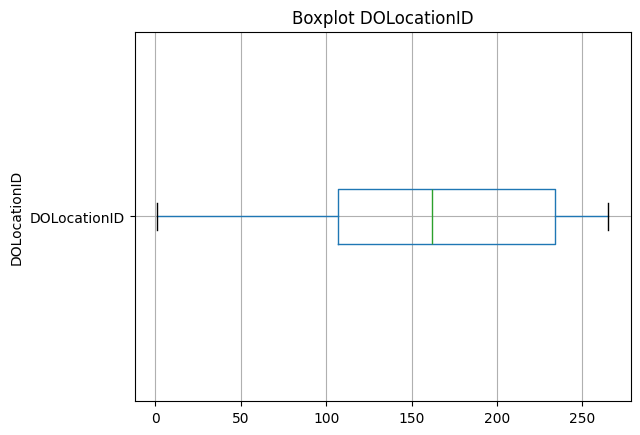

In [ ]:
# Graficar Boxplot para la variable "VendorID" del conjunto de datos
df_numerico.boxplot(column="DOLocationID", vert=False)
plt.title("Boxplot DOLocationID")
plt.ylabel("DOLocationID")
plt.show()

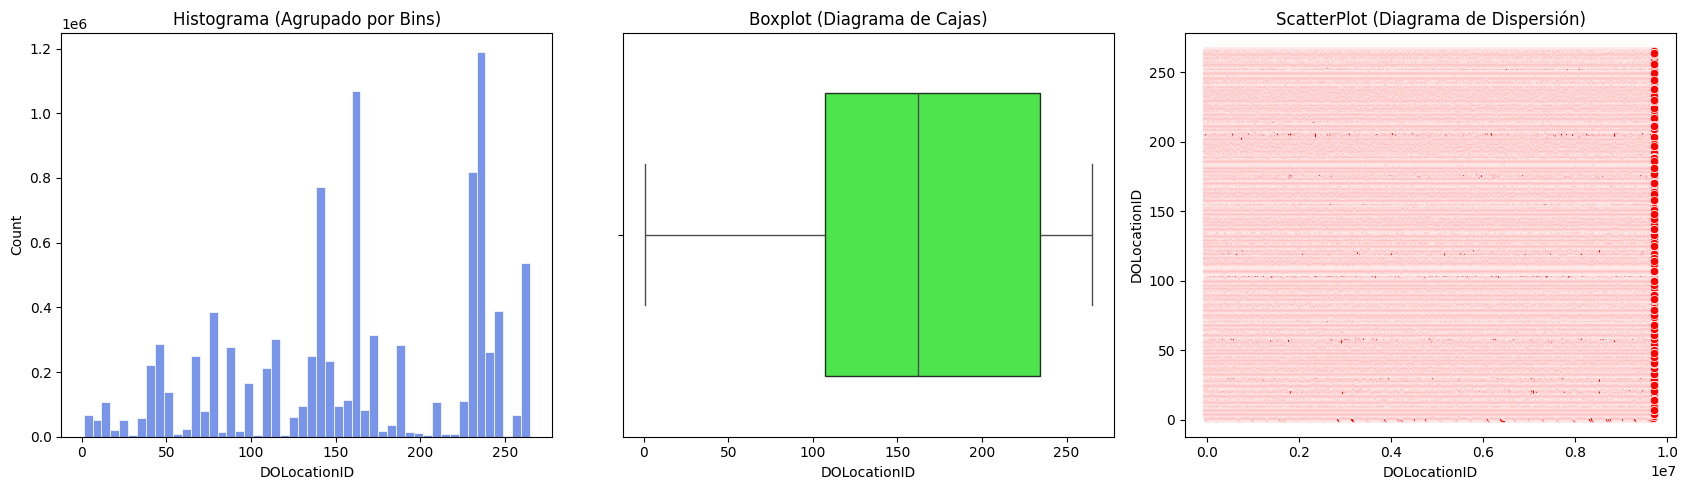

In [ ]:
mostrarGraficas("DOLocationID")

### **2.3.7 payment_type**

In [ ]:
# Obtener los valores unicos de la columna "payment_type"
data = df_numerico["payment_type"].unique()
data.sort()
print(data)

[1 2 3 4 5]


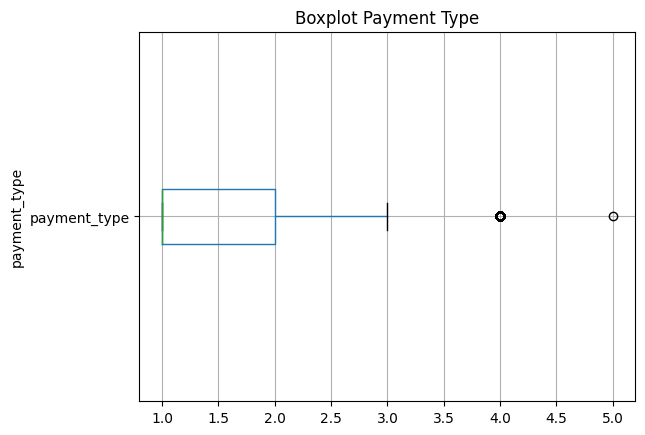

In [ ]:
# Graficar Boxplot para la variable "payment_type" del conjunto de datos
df_numerico.boxplot(column="payment_type", vert=False)
plt.title("Boxplot Payment Type")
plt.ylabel("payment_type")
plt.show()

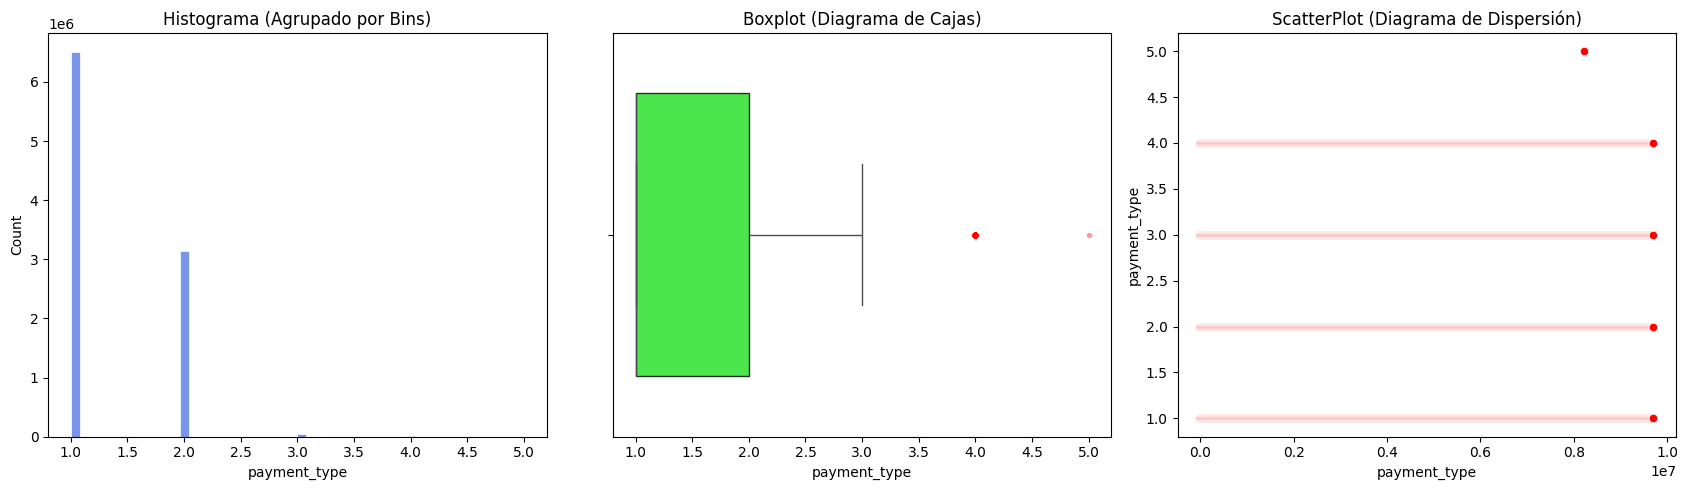

In [ ]:
mostrarGraficas("payment_type")

### **2.3.8 fare_amount**

In [ ]:
# Obtener los valores unicos de la columna "fare_amount"
data = df_numerico["fare_amount"].unique()
data.sort()
print(len(data)) # Se encontraron 1783 valores distintos
print(data)

1783
[-3.500000e+02 -3.000000e+02 -1.920000e+02 ...  9.000500e+03  5.385792e+05
  6.259008e+05]


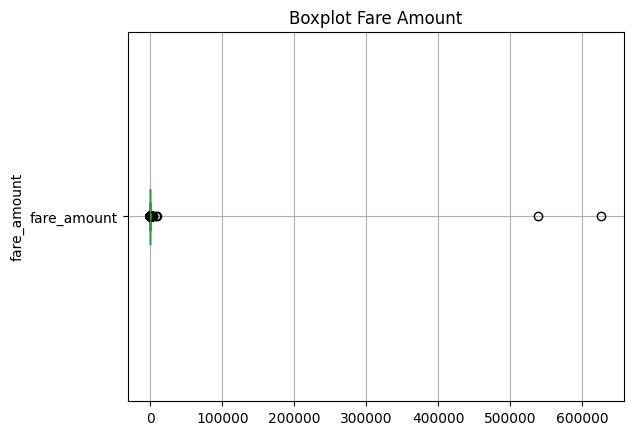

In [ ]:
# Graficar Boxplot para la variable "fare_amount" del conjunto de datos
df_numerico.boxplot(column="fare_amount", vert=False)
plt.title("Boxplot Fare Amount")
plt.ylabel("fare_amount")
plt.show()

### **2.3.9 extra**

In [ ]:
# Obtener los valores unicos de la columna "extra"
data = df_numerico["extra"].unique()
data.sort()
print(len(data)) # Se encontraron 30 valores distintos
print(data)

30
[-5.520e+01 -2.658e+01 -1.360e+01 -4.500e+00 -3.590e+00 -1.000e+00
 -5.000e-01 -4.500e-01 -3.000e-02  0.000e+00  2.000e-02  3.000e-01
  4.500e-01  5.000e-01  7.000e-01  8.000e-01  9.500e-01  1.000e+00
  1.300e+00  1.500e+00  1.800e+00  2.000e+00  4.500e+00  4.540e+00
  5.000e+00  5.500e+00  1.200e+01  2.020e+01  2.800e+01  5.554e+01]


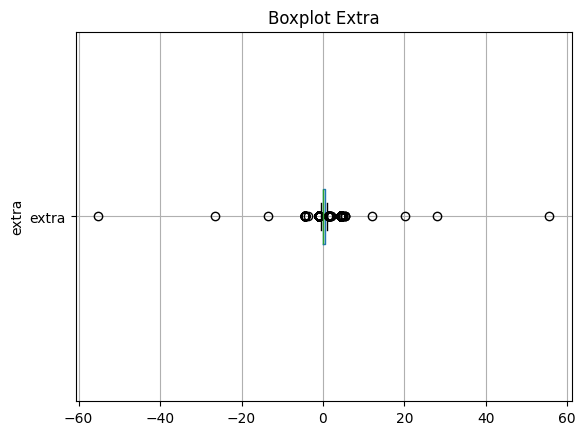

In [ ]:
# Graficar Boxplot para la variable "extra" del conjunto de datos
df_numerico.boxplot(column="extra", vert=False)
plt.title("Boxplot Extra")
plt.ylabel("extra")
plt.show()

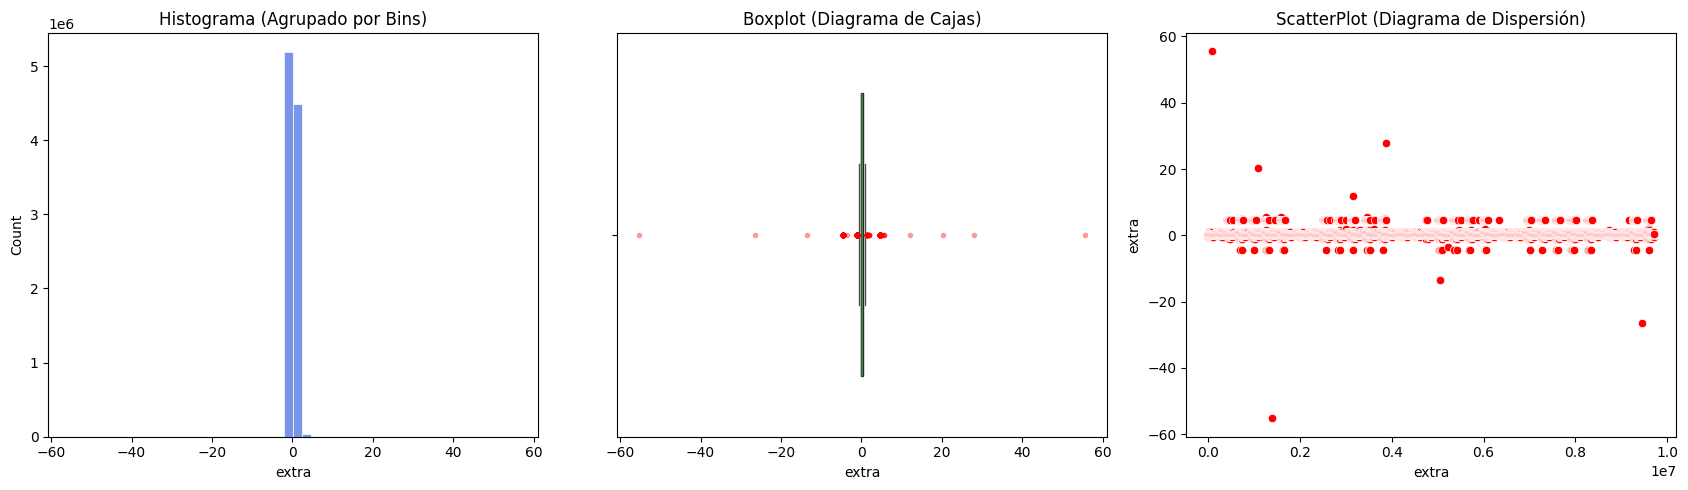

In [ ]:
mostrarGraficas("extra")

### **2.3.10 mta_tax**

In [ ]:
# Obtener los valores unicos de la columna "mta_tax"
data = df_numerico["mta_tax"].unique()
data.sort()
print(len(data)) # Se encontraron 10 valores distintos
print(data)

10
[-0.5   0.    0.35  0.5   0.83  4.39 15.4  27.38 49.34 56.5 ]


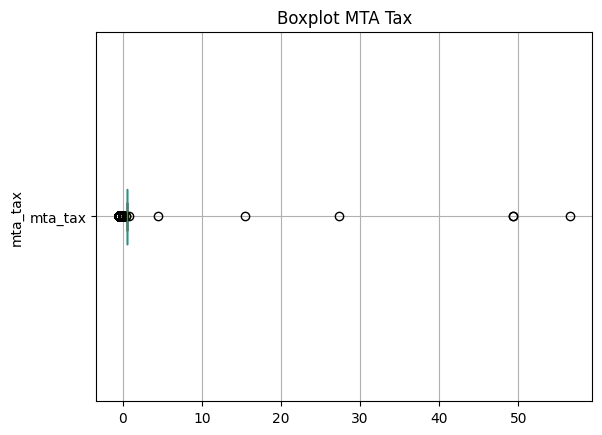

In [ ]:
# Graficar Boxplot para la variable "mta_tax" del conjunto de datos
df_numerico.boxplot(column="mta_tax", vert=False)
plt.title("Boxplot MTA Tax")
plt.ylabel("mta_tax")
plt.show()

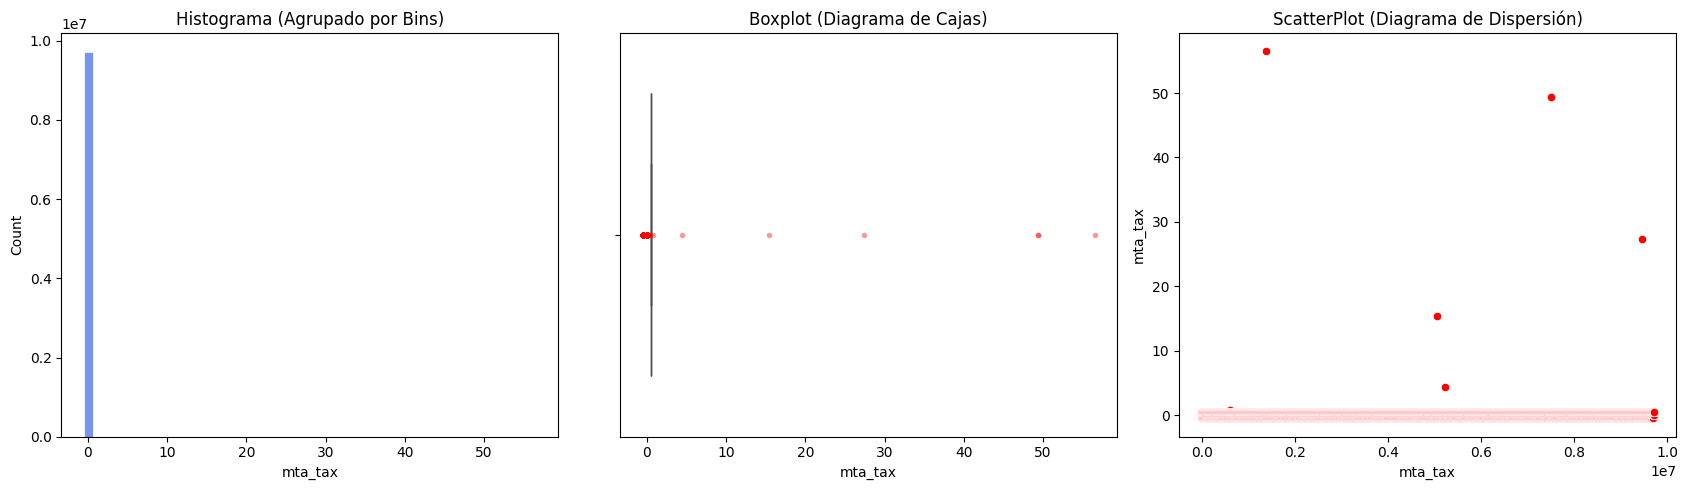

In [ ]:
mostrarGraficas("mta_tax")

### **2.3.11 tip_amount**

In [ ]:
# Obtener los valores unicos de la columna "Tip_Amount"
data = df_numerico["tip_amount"].unique()
data.sort()
print(len(data)) # Se encontraron 3451 valores distintos
print(data)

3451
[-41.   -25.06 -16.   ... 371.   393.94 999.99]


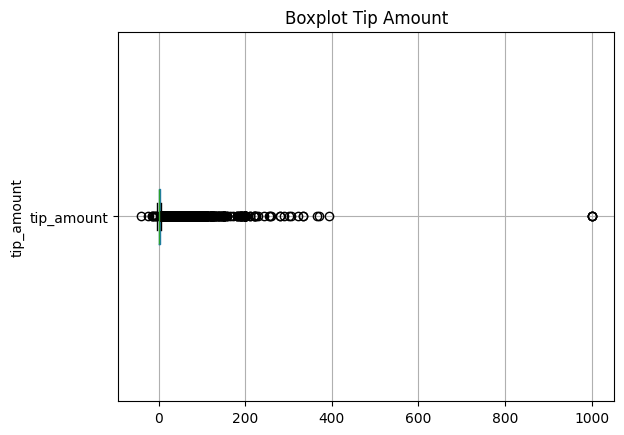

In [ ]:
# Graficar Boxplot para la variable "tip_Amount" del conjunto de datos
df_numerico.boxplot(column="tip_amount", vert=False)
plt.title("Boxplot Tip Amount")
plt.ylabel("tip_amount")
plt.show()

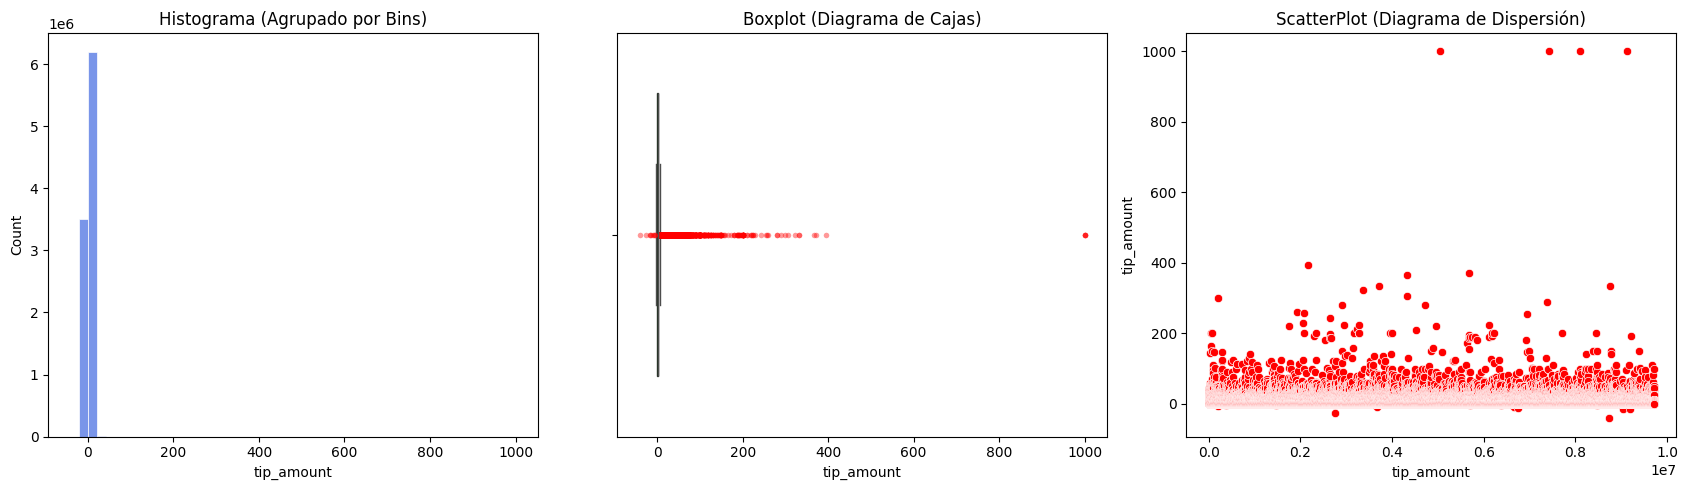

In [ ]:
mostrarGraficas("tip_amount")

### **2.3.12 tolls_amount**

In [ ]:
# Obtener los valores unicos de la columna "Tolls Amount"
data = df_numerico["tolls_amount"].unique()
data.sort()
print(len(data)) # Se encontraron 884 valores distintos
print(data)

884
[-1.5000e+01 -1.4500e+01 -1.2500e+01 -1.0500e+01 -8.0000e+00 -5.5400e+00
  0.0000e+00  1.0000e-02  2.0000e-02  3.0000e-02  4.0000e-02  5.0000e-02
  6.0000e-02  7.0000e-02  8.0000e-02  9.0000e-02  1.0000e-01  1.2000e-01
  1.8000e-01  2.0000e-01  2.5000e-01  3.0000e-01  3.3000e-01  5.0000e-01
  5.4000e-01  5.8000e-01  6.0000e-01  7.0000e-01  7.4000e-01  7.5000e-01
  9.0000e-01  1.0000e+00  1.0100e+00  1.0400e+00  1.0700e+00  1.1000e+00
  1.1600e+00  1.2000e+00  1.3500e+00  1.4000e+00  1.5000e+00  1.5400e+00
  1.6200e+00  1.7500e+00  1.8000e+00  1.9000e+00  2.0000e+00  2.0400e+00
  2.0800e+00  2.1500e+00  2.1600e+00  2.2000e+00  2.2100e+00  2.2400e+00
  2.2500e+00  2.3000e+00  2.3200e+00  2.4000e+00  2.4400e+00  2.4500e+00
  2.5000e+00  2.5200e+00  2.5400e+00  2.5500e+00  2.7000e+00  2.7500e+00
  2.8000e+00  2.8500e+00  2.8800e+00  2.9000e+00  2.9500e+00  2.9900e+00
  3.0000e+00  3.0800e+00  3.2500e+00  3.3000e+00  3.3400e+00  3.4000e+00
  3.5000e+00  3.5400e+00  3.7000e+00  3.7500e+0

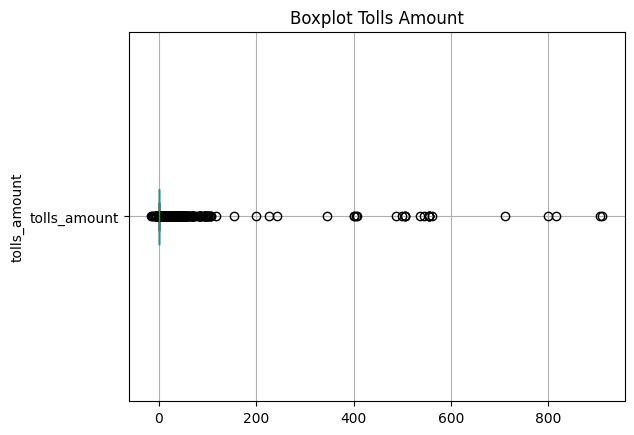

In [ ]:
# Graficar Boxplot para la variable "tolls_amount" del conjunto de datos
df_numerico.boxplot(column="tolls_amount", vert=False)
plt.title("Boxplot Tolls Amount")
plt.ylabel("tolls_amount")
plt.show()

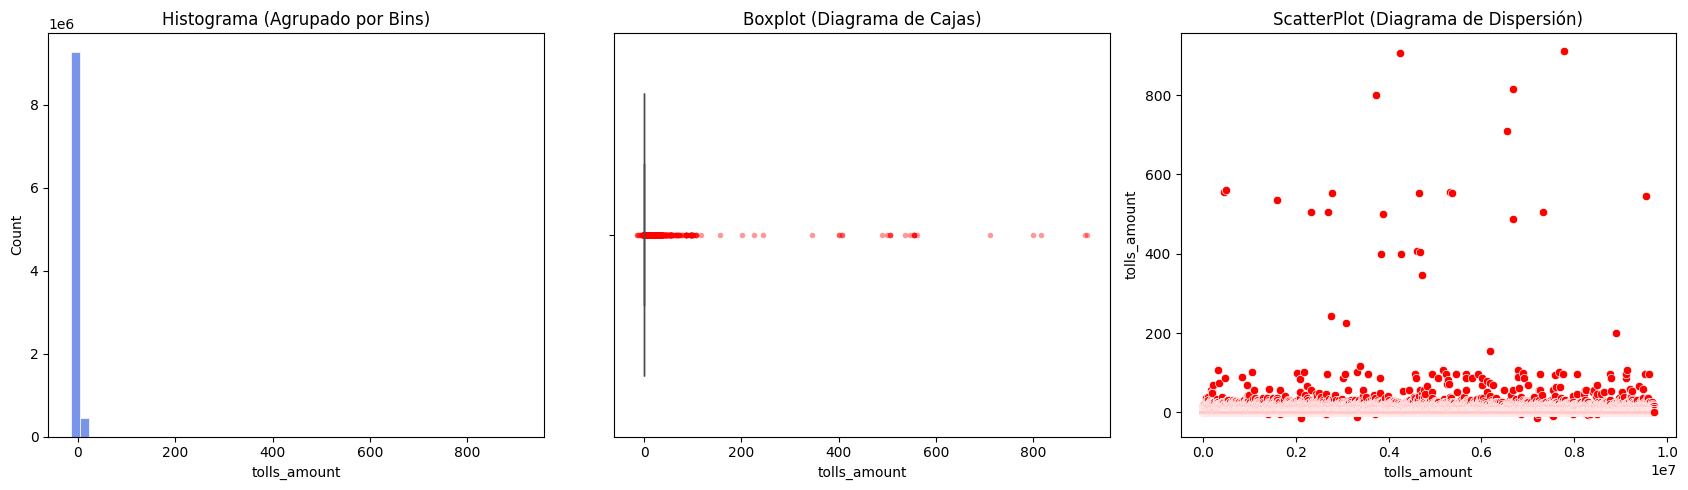

In [ ]:
mostrarGraficas("tolls_amount")

### **2.3.13 Improvement Surcharge**

In [ ]:
# Obtener los valores unicos de la columna "improvement_surcharge"
data = df_numerico["improvement_surcharge"].unique()
data.sort()
print(len(data)) # Se encontraron 3 valores distintos
print(data)

3
[-0.3  0.   0.3]


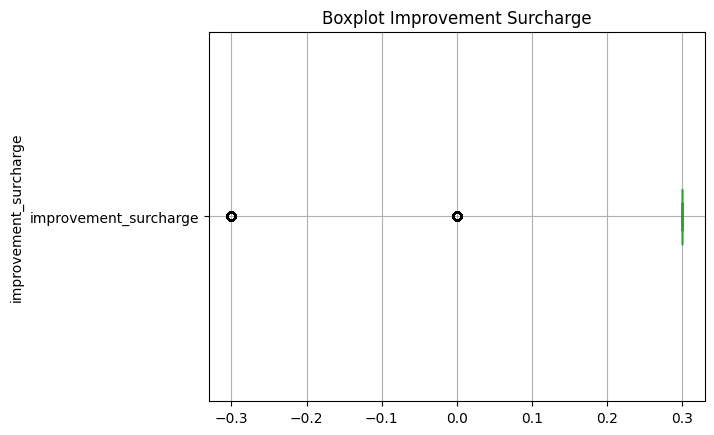

In [ ]:
# Graficar Boxplot para la variable "improvement_surcharge" del conjunto de datos
df_numerico.boxplot(column="improvement_surcharge", vert=False)
plt.title("Boxplot Improvement Surcharge")
plt.ylabel("improvement_surcharge")
plt.show()

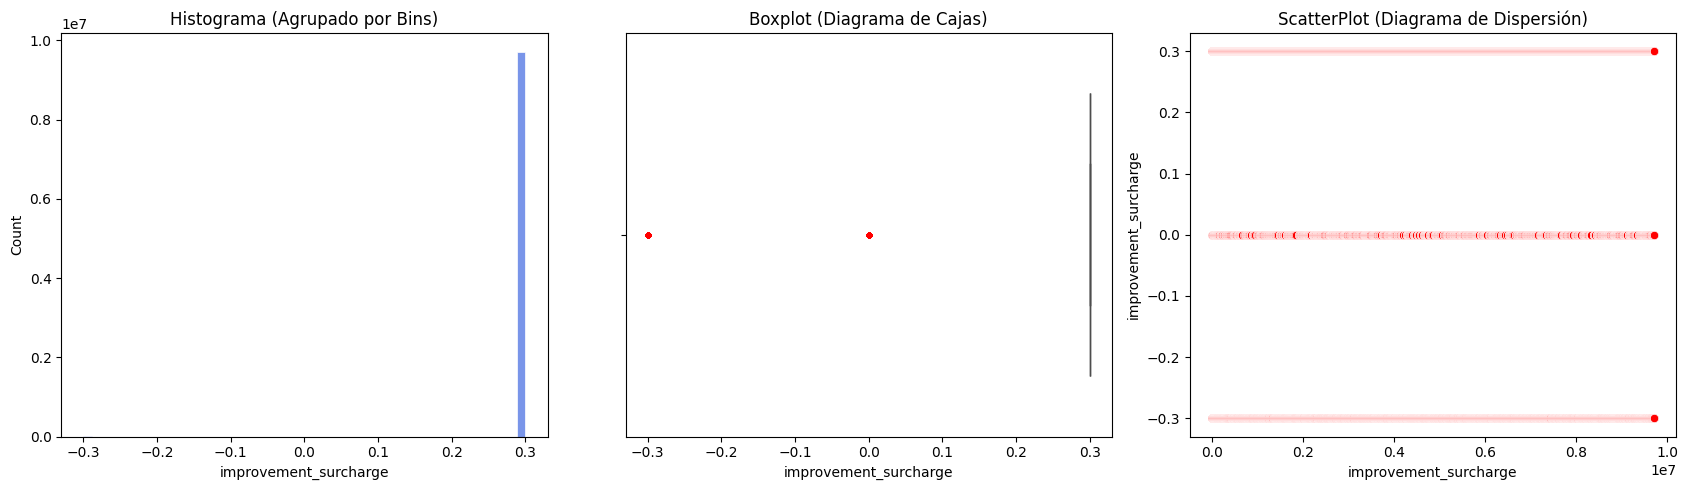

In [ ]:
mostrarGraficas("improvement_surcharge")

### **2.3.14 total_amount**

In [ ]:
# Obtener los valores unicos de la columna "Total Amount"
data = df_numerico["total_amount"].unique()
data.sort()
print(len(data)) # Se encontraron 11101 valores distintos
print(data)

11101
[-3.503000e+02 -3.003000e+02 -1.928000e+02 ...  9.001300e+03  5.385800e+05
  6.259016e+05]


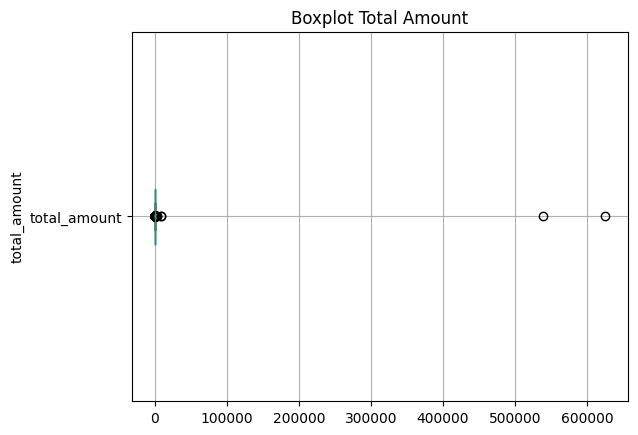

In [ ]:
# Graficar Boxplot para la variable "total_amount" del conjunto de datos
df_numerico.boxplot(column="total_amount", vert=False)
plt.title("Boxplot Total Amount")
plt.ylabel("total_amount")
plt.show()

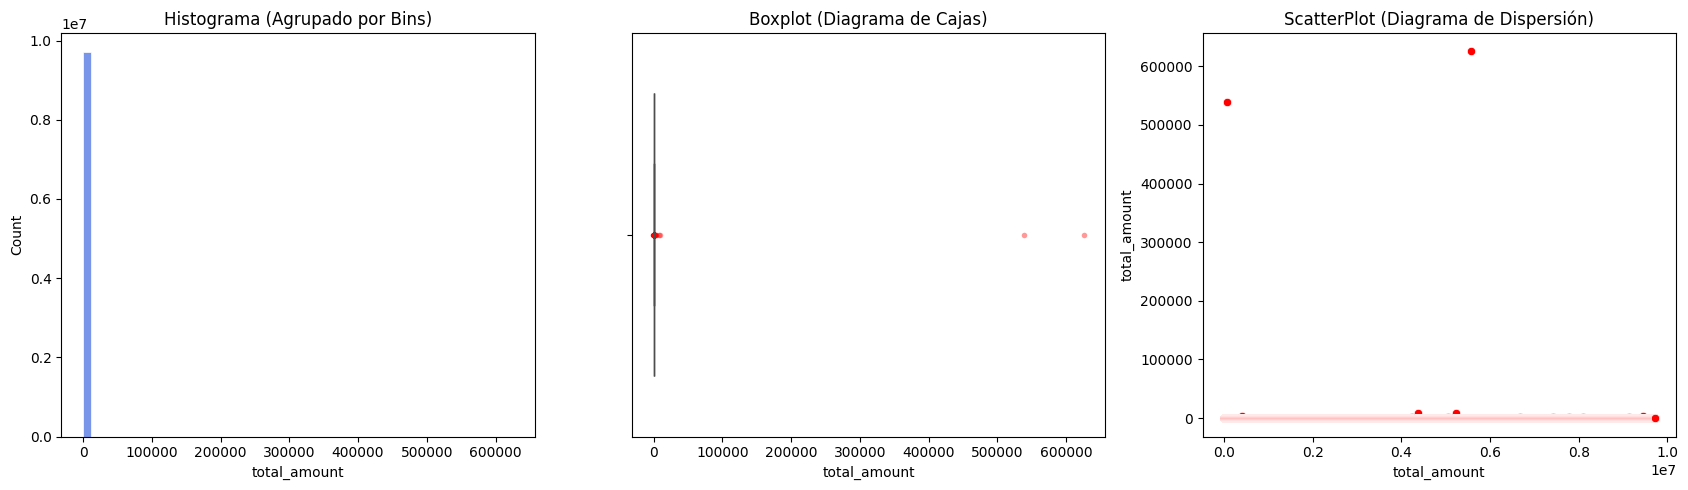

In [ ]:
mostrarGraficas("total_amount")